In [1]:
import os

import random

import numpy as np

import cv2

import matplotlib.pyplot as plt
import seaborn as sns

from keras.applications import Xception
from keras.models import Sequential
from keras import layers
from keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tqdm.notebook import tqdm

2025-05-08 11:55:07.272157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746705307.456920      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746705307.509770      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [31]:
from keras.applications import Xception

In [2]:
IMG_SIZE = 196

In [3]:
def apply_preprocessing(img, img_size=IMG_SIZE):
    # 1. BGR'den RGB'ye çevir
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = img_rgb.shape[:2]

    # 2. Kontur ile içerik kırpma (orijinal boyutta)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        contour = max(contours, key=cv2.contourArea)[:, 0, :]
        x1, y1 = np.min(contour, axis=0)
        x2, y2 = np.max(contour, axis=0)

        if (x2 - x1 > w_orig // 6) and (y2 - y1 > h_orig // 6):
            x_margin = int((x2 - x1) * 0.08)
            y_margin = int((y2 - y1) * 0.08)

            x1 = max(0, x1 - x_margin)
            y1 = max(0, y1 - y_margin)
            x2 = min(w_orig, x2 + x_margin)
            y2 = min(h_orig, y2 + y_margin)

            img_rgb = img_rgb[y1:y2, x1:x2]

    # 3. Resize
    img_rgb = cv2.resize(img_rgb, (img_size, img_size))

    # 4. CLAHE uygulama (istenirse)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    lab = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    """# 5. Blur çıkarımı (isteğe bağlı — test et)
    med_blur = cv2.medianBlur(img_clahe, 3)
    background = cv2.medianBlur(img_clahe, 37)
    mask = cv2.subtract(med_blur, background)
    mask = cv2.normalize(mask, None, 0, 255, cv2.NORM_MINMAX)
    img_final = cv2.bitwise_and(mask, med_blur)"""
    return img_clahe

In [4]:
labels = ["0", "1", "2", "3", "4"]
img_size = IMG_SIZE

In [5]:
def get_data(data_dir):  # train setindeki hasta sayısı ile sınırlandır

    data = list()

    for label in labels:
        class_id = labels.index(label)  # 'NORMAL' = 0, 'STROKE' = 1
        main_dir = os.path.join(os.getcwd(), data_dir)
        main_dir = os.path.join(main_dir, label)

        for img_name in tqdm(os.listdir(main_dir)):

            try:
                # read image
                img = cv2.imread(os.path.join(main_dir, img_name), cv2.IMREAD_COLOR)

                # apply preprocessing
                img = apply_preprocessing(img, img_size)
                data.append([img, class_id])


            except Exception as e:
                print(e)

    return data

In [6]:

test = get_data("/kaggle/input/blindlessdetection/TEST/TEST")

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

In [7]:
train = get_data("/kaggle/input/blindlessdetection/TRAIN/TRAIN") 

  0%|          | 0/1181 [00:00<?, ?it/s]

  0%|          | 0/1054 [00:00<?, ?it/s]

  0%|          | 0/1122 [00:00<?, ?it/s]

  0%|          | 0/1159 [00:00<?, ?it/s]

  0%|          | 0/1168 [00:00<?, ?it/s]

In [8]:
train = np.array(train, dtype='object')
test = np.array(test, dtype='object')

In [9]:
x_train, y_train = list(), list()
x_test, y_test = list(), list()

for feat, label in train:
    x_train.append(feat)  # görseller
    y_train.append(label)  # etiketler

In [10]:
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)

In [11]:
# normalization : [0,255] -> [0,1]

x_train = np.array(x_train) / 255
x_test = np.array(x_test) / 255

In [12]:
x_train = x_train.reshape(-1, img_size, img_size, 3)  # -1 : oto 
x_test = x_test.reshape(-1, img_size, img_size, 3)

In [13]:

y_train = np.array(y_train)
y_test = np.array(y_test)

In [39]:
model_name = "Xception"

model = Sequential()
model.add(Xception(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3)))
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.3))  # Daha az dropout
model.add(layers.Dense(5, activation='softmax'))  # sigmoid yerine softmax

In [40]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [41]:
lr = ReduceLROnPlateau(monitor='val_loss',
                       patience=3,
                       verbose=1,
                       mode='auto',
                       factor=0.25,
                       min_lr=1e-6)

In [43]:
history = model.fit(x_train, y_train,
                    batch_size=20,
                    epochs=8, # 
                    validation_data=(x_test, y_test),
                    callbacks=[lr])

285/285 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - accuracy: 0.9930 - loss: 0.0268 - val_accuracy: 0.8396 - val_loss: 0.6129 - learning_rate: 2.5000e-04


In [44]:

# Modelin tahminleri
y_pred_probs = model.predict(x_test)  # softmax çıktıları
y_pred = np.argmax(y_pred_probs, axis=1)  # en yüksek olasılığı al

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step


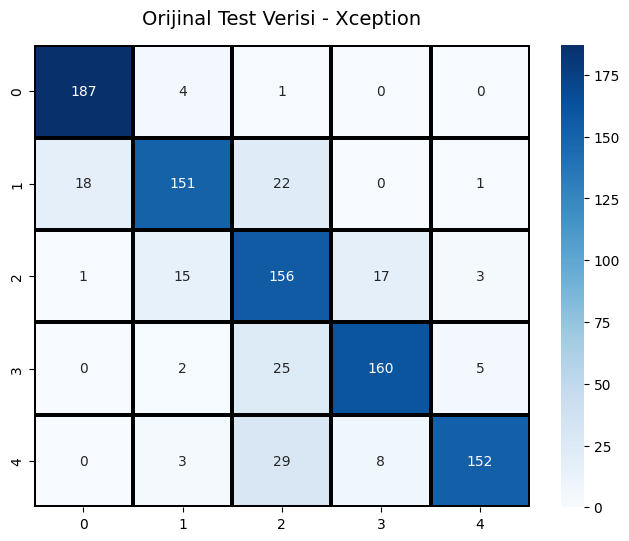

In [45]:
cm = confusion_matrix(y_test, y_pred)

# Isı haritası çiz
plt.figure(figsize=(8, 6))  # Daha büyük bir figür boyutu
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", linewidths=1.5, linecolor='black',
            xticklabels=set(y_test), yticklabels=set(y_test))

plt.title(f"Orijinal Test Verisi - {model_name}", fontsize=14, pad=15)
plt.show()

In [46]:

print("accuracy : \n", accuracy_score(y_test, y_pred))
print("cr : \n", classification_report(y_test, y_pred))

accuracy : 
 0.8395833333333333
cr : 
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       192
           1       0.86      0.79      0.82       192
           2       0.67      0.81      0.73       192
           3       0.86      0.83      0.85       192
           4       0.94      0.79      0.86       192

    accuracy                           0.84       960
   macro avg       0.85      0.84      0.84       960
weighted avg       0.85      0.84      0.84       960



In [47]:
model.save(f"{model_name}.h5")